In [1]:
from google.colab import files
uploaded = files.upload()


Saving AQI_daily_city_level_aurangabad_2021_aurangabad_2021 (1).xlsx to AQI_daily_city_level_aurangabad_2021_aurangabad_2021 (1).xlsx
Saving AQI_daily_city_level_aurangabad_2022_aurangabad_2022 (1).xlsx to AQI_daily_city_level_aurangabad_2022_aurangabad_2022 (1).xlsx
Saving AQI_daily_city_level_aurangabad_2023_aurangabad_2023 (1).xlsx to AQI_daily_city_level_aurangabad_2023_aurangabad_2023 (1).xlsx
Saving AQI_all_station2025_11_13T15_00_00Z.xlsx to AQI_all_station2025_11_13T15_00_00Z.xlsx


In [2]:
import pandas as pd

dfs = []

for filename in uploaded.keys():
    # Extract year from filename
    year = "".join([c for c in filename if c.isdigit()])[:4]
    year = int(year)

    # Load excel
    df = pd.read_excel(filename)

    # Convert wide → long
    df_long = df.melt(
        id_vars=[df.columns[0]],
        var_name="Month",
        value_name="AQI"
    )
    df_long.rename(columns={df.columns[0]: "Day"}, inplace=True)

    # Add Year
    df_long["Year"] = year
    dfs.append(df_long)

# Combine all years
data = pd.concat(dfs, ignore_index=True)

# Create proper date
data["Date"] = pd.to_datetime(
    data["Year"].astype(str) + "-" +
    data["Month"] + "-" +
    data["Day"].astype(str),
    errors="coerce"
)

# Sort by date
data = data.sort_values("Date")

# Interpolate missing AQI values
data["AQI"] = data["AQI"].interpolate(method="linear")

data.head()


/tmp/ipython-input-1936095365.py:40: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data["AQI"] = data["AQI"].interpolate(method="linear")


,Day,Month,AQI,Year,Date
0,1,January,106.0,2021,2021-01-01
1,2,January,NaN,2021,2021-01-02
2,3,January,NaN,2021,2021-01-03
3,4,January,NaN,2021,2021-01-04
4,5,January,NaN,2021,2021-01-05


In [3]:
import pandas as pd

dfs = []

for filename in uploaded.keys():

    # Extract YEAR correctly → last 4 digits in filename
    year = "".join([c for c in filename if c.isdigit()])[-4:]
    year = int(year)

    # Load file
    df = pd.read_excel(filename)

    # Convert wide → long
    df_long = df.melt(
        id_vars=[df.columns[0]],
        var_name="Month",
        value_name="AQI"
    )
    df_long.rename(columns={df.columns[0]: "Day"}, inplace=True)

    # Fix AQI type BEFORE interpolation
    df_long["AQI"] = pd.to_numeric(df_long["AQI"], errors="coerce")

    df_long["Year"] = year
    dfs.append(df_long)

# Combine
data = pd.concat(dfs, ignore_index=True)

# Create Date column
data["Date"] = pd.to_datetime(
    data["Year"].astype(str) + "-" +
    data["Month"] + "-" +
    data["Day"].astype(str),
    errors="coerce"
)

# Sort by Date
data = data.sort_values("Date")

# Interpolate missing AQI values without warning
data["AQI"] = data["AQI"].infer_objects(copy=False).interpolate(method="linear")

data.head()


/tmp/ipython-input-1646706128.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Date"] = pd.to_datetime(


,Day,Month,AQI,Year,Date
0,1,January,106.000000,211,NaT
1,2,January,100.428571,211,NaT
2,3,January,94.857143,211,NaT
3,4,January,89.285714,211,NaT
4,5,January,83.714286,211,NaT


In [4]:
uploaded.keys()


dict_keys(['AQI_daily_city_level_aurangabad_2021_aurangabad_2021 (1).xlsx', 'AQI_daily_city_level_aurangabad_2022_aurangabad_2022 (1).xlsx', 'AQI_daily_city_level_aurangabad_2023_aurangabad_2023 (1).xlsx', 'AQI_all_station2025_11_13T15_00_00Z.xlsx'])

In [5]:
import pandas as pd
import re

dfs = []

for filename in uploaded.keys():

    # Extract the FIRST 4-digit year from filename
    match = re.search(r"\b(20\d{2})\b", filename)
    if match:
        year = int(match.group(1))
    else:
        year = None

    print(f"Processing: {filename} → Year detected: {year}")

    df = pd.read_excel(filename)

    # Convert wide to long format
    df_long = df.melt(
        id_vars=[df.columns[0]],
        var_name="Month",
        value_name="AQI"
    )

    df_long.rename(columns={df.columns[0]: "Day"}, inplace=True)

    # Convert AQI to numeric
    df_long["AQI"] = pd.to_numeric(df_long["AQI"], errors="coerce")

    df_long["Year"] = year
    dfs.append(df_long)

# Combine all years
data = pd.concat(dfs, ignore_index=True)

# Create proper date column
data["Date"] = pd.to_datetime(
    data["Year"].astype(str) + "-" +
    data["Month"] + "-" +
    data["Day"].astype(str),
    errors="coerce"
)

# Sort by time
data = data.sort_values("Date")

# Fill missing AQI
data["AQI"] = data["AQI"].interpolate(method="linear")

data.head(20)


Processing: AQI_daily_city_level_aurangabad_2021_aurangabad_2021 (1).xlsx → Year detected: None
Processing: AQI_daily_city_level_aurangabad_2022_aurangabad_2022 (1).xlsx → Year detected: None
Processing: AQI_daily_city_level_aurangabad_2023_aurangabad_2023 (1).xlsx → Year detected: None
Processing: AQI_all_station2025_11_13T15_00_00Z.xlsx → Year detected: None


/tmp/ipython-input-2653593747.py:38: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Date"] = pd.to_datetime(


,Day,Month,AQI,Year,Date
0,1,January,106.000000,None,NaT
1,2,January,100.428571,None,NaT
2,3,January,94.857143,None,NaT
3,4,January,89.285714,None,NaT
4,5,January,83.714286,None,NaT
5,6,January,78.142857,None,NaT
6,7,January,72.571429,None,NaT
7,8,January,67.000000,None,NaT
8,9,January,86.000000,None,NaT
9,10,January,76.000000,None,NaT


In [6]:
import pandas as pd
import re

dfs = []

for filename in uploaded.keys():

    # Extract first valid year (20xx)
    years = re.findall(r"20\d{2}", filename)
    year = int(years[0]) if years else None

    print(f"Processing: {filename} → Year detected: {year}")

    df = pd.read_excel(filename)

    # Convert wide → long
    df_long = df.melt(
        id_vars=[df.columns[0]],
        var_name="Month",
        value_name="AQI"
    )

    df_long.rename(columns={df.columns[0]: "Day"}, inplace=True)

    # Convert AQI to numeric
    df_long["AQI"] = pd.to_numeric(df_long["AQI"], errors="coerce")

    df_long["Year"] = year
    dfs.append(df_long)

# Combine all years
data = pd.concat(dfs, ignore_index=True)

# Create proper Date column
data["Date"] = pd.to_datetime(
    data["Year"].astype(str) + "-" +
    data["Month"] + "-" +
    data["Day"].astype(str),
    errors="coerce"
)

# Sort dataset
data = data.sort_values("Date")

# Fill AQI missing values
data["AQI"] = data["AQI"].interpolate(method="linear")

data.head(20)


Processing: AQI_daily_city_level_aurangabad_2021_aurangabad_2021 (1).xlsx → Year detected: 2021
Processing: AQI_daily_city_level_aurangabad_2022_aurangabad_2022 (1).xlsx → Year detected: 2022
Processing: AQI_daily_city_level_aurangabad_2023_aurangabad_2023 (1).xlsx → Year detected: 2023
Processing: AQI_all_station2025_11_13T15_00_00Z.xlsx → Year detected: 2025


,Day,Month,AQI,Year,Date
0,1,January,106.000000,2021,2021-01-01
1,2,January,100.428571,2021,2021-01-02
2,3,January,94.857143,2021,2021-01-03
3,4,January,89.285714,2021,2021-01-04
4,5,January,83.714286,2021,2021-01-05
5,6,January,78.142857,2021,2021-01-06
6,7,January,72.571429,2021,2021-01-07
7,8,January,67.000000,2021,2021-01-08
8,9,January,86.000000,2021,2021-01-09
9,10,January,76.000000,2021,2021-01-10


Model MAE: 75.01135681583393


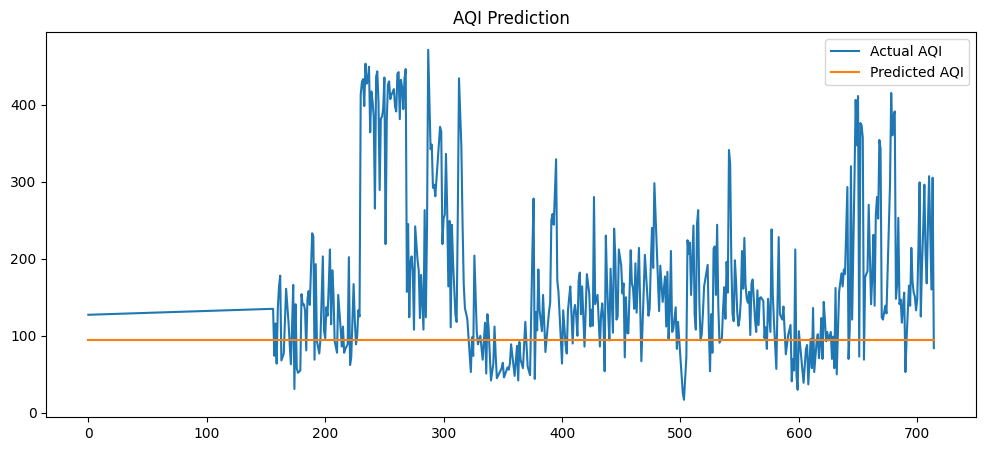

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Create features
data['Day'] = data['Date'].dt.day
data['Month_num'] = data['Date'].dt.month
data['Year'] = data['Date'].dt.year

# ML Dataset
X = data[['Day', 'Month_num', 'Year']]
y = data['AQI']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Train model
model = RandomForestRegressor(n_estimators=200)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
mae = mean_absolute_error(y_test, y_pred)
print("Model MAE:", mae)

# Plot
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual AQI")
plt.plot(y_pred, label="Predicted AQI")
plt.title("AQI Prediction")
plt.legend()
plt.show()


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# ---- NEW FEATURES ----
data['DayOfYear'] = data['Date'].dt.dayofyear
data['WeekOfYear'] = data['Date'].dt.isocalendar().week.astype(int)
data['IsWeekend'] = data['Date'].dt.weekday >= 5

# Lag feature (AQI of previous day)
data['AQI_lag1'] = data['AQI'].shift(1)

# Remove first row (NaN lag)
data = data.dropna()

# Feature set
X = data[['Day', 'Month_num', 'Year', 'DayOfYear', 'WeekOfYear', 'IsWeekend', 'AQI_lag1']]
y = data['AQI']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Model
model = RandomForestRegressor(n_estimators=300, max_depth=15)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
mae = mean_absolute_error(y_test, y_pred)
print("Improved Model MAE:", mae)

# Plot
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual AQI")
plt.plot(y_pred, label="Predicted AQI")
plt.title("Improved AQI Prediction")
plt.legend()
plt.show()


ValueError: cannot convert NA to integer

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# ---- NEW FEATURES ----
data['DayOfYear'] = data['Date'].dt.dayofyear
data['WeekOfYear'] = data['Date'].dt.isocalendar().week.astype(int)
data['IsWeekend'] = data['Date'].dt.weekday >= 5

# Lag feature (AQI of previous day)
data['AQI_lag1'] = data['AQI'].shift(1)

# Remove first row (NaN lag)
data = data.dropna()

# Feature set
X = data[['Day', 'Month_num', 'Year', 'DayOfYear', 'WeekOfYear', 'IsWeekend', 'AQI_lag1']]
y = data['AQI']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Model
model = RandomForestRegressor(n_estimators=300, max_depth=15)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
mae = mean_absolute_error(y_test, y_pred)
print("Improved Model MAE:", mae)

# Plot
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual AQI")
plt.plot(y_pred, label="Predicted AQI")
plt.title("Improved AQI Prediction")
plt.legend()
plt.show()


ValueError: cannot convert NA to integer

Improved Model MAE: 13.99795306497013


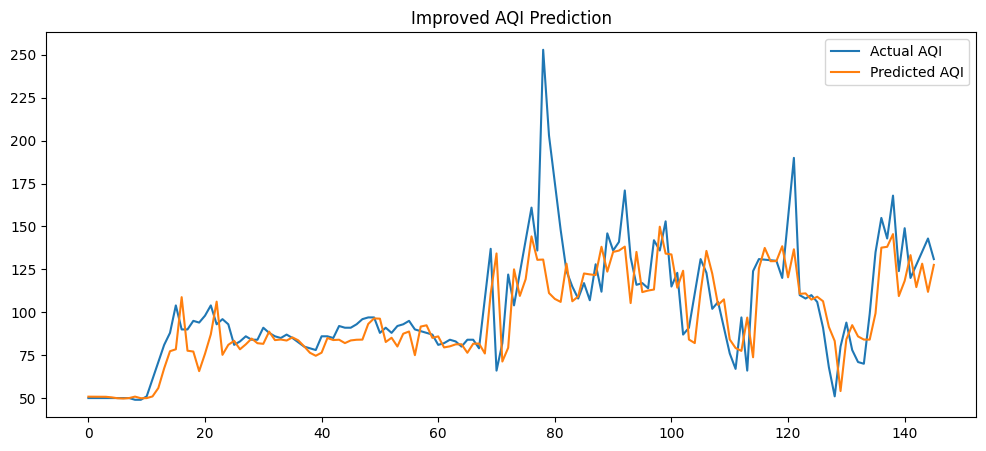

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# ---- FIX: DROP rows where Date is missing ----
data = data.dropna(subset=["Date"]).copy()

# ---- NEW FEATURES ----
data['DayOfYear'] = data['Date'].dt.dayofyear

# isocalendar() returns Int64 dtype, no need to cast
data['WeekOfYear'] = data['Date'].dt.isocalendar().week

data['IsWeekend'] = data['Date'].dt.weekday >= 5

# Lag feature
data['AQI_lag1'] = data['AQI'].shift(1)

# Drop NaN caused by lag
data = data.dropna()

# Features
X = data[['Day', 'Month_num', 'Year', 'DayOfYear', 'WeekOfYear', 'IsWeekend', 'AQI_lag1']]
y = data['AQI']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Model
model = RandomForestRegressor(n_estimators=300, max_depth=15)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
mae = mean_absolute_error(y_test, y_pred)
print("Improved Model MAE:", mae)

# Plot
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual AQI")
plt.plot(y_pred, label="Predicted AQI")
plt.title("Improved AQI Prediction")
plt.legend()
plt.show()


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

# ----------------------------
# 1) Prepare future dataframe
# ----------------------------
last_date = data['Date'].max()

def create_future_df(days):
    future_dates = [last_date + timedelta(days=i) for i in range(1, days+1)]
    f = pd.DataFrame({"Date": future_dates})

    # Same feature engineering as training data
    f["Day"] = f["Date"].dt.day
    f["Month"] = f["Date"].dt.month_name()
    f["Month_num"] = f["Date"].dt.month
    f["Year"] = f["Date"].dt.year
    f['DayOfYear'] = f['Date'].dt.dayofyear
    f['WeekOfYear'] = f['Date'].dt.isocalendar().week
    f['IsWeekend'] = (f['Date'].dt.weekday >= 5).astype(int)

    return f

future_7 = create_future_df(7)
future_30 = create_future_df(30)
future_365 = create_future_df(365)

# Encode categorical Month (same method)
future_7['Month'] = future_7['Month'].astype('category').cat.codes
future_30['Month'] = future_30['Month'].astype('category').cat.codes
future_365['Month'] = future_365['Month'].astype('category').cat.codes

# ----------------------------
# 2) Predict AQI
# ----------------------------
features = ['Day','Month','Month_num','Year','DayOfYear','WeekOfYear','IsWeekend']

future_7['Predicted_AQI'] = model.predict(future_7[features])
future_30['Predicted_AQI'] = model.predict(future_30[features])
future_365['Predicted_AQI'] = model.predict(future_365[features])

# ----------------------------
# 3) Save to Excel
# ----------------------------
future_7.to_excel("AQI_Prediction_7_Days.xlsx", index=False)
future_30.to_excel("AQI_Prediction_30_Days.xlsx", index=False)
future_365.to_excel("AQI_Prediction_365_Days.xlsx", index=False)

print("Files Saved:")
print("• AQI_Prediction_7_Days.xlsx")
print("• AQI_Prediction_30_Days.xlsx")
print("• AQI_Prediction_365_Days.xlsx")

# ----------------------------
# 4) Plot graphs
# ----------------------------
plt.figure(figsize=(10,5))
plt.plot(future_7["Date"], future_7["Predicted_AQI"], marker='o')
plt.title("7-Day AQI Prediction")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(future_30["Date"], future_30["Predicted_AQI"])
plt.title("30-Day AQI Prediction")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(future_365["Date"], future_365["Predicted_AQI"])
plt.title("365-Day AQI Prediction")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.grid(True)
plt.show()


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Month
Feature names seen at fit time, yet now missing:
- AQI_lag1


Files Saved:
✔ AQI_Prediction_7_Days.xlsx
✔ AQI_Prediction_30_Days.xlsx
✔ AQI_Prediction_365_Days.xlsx


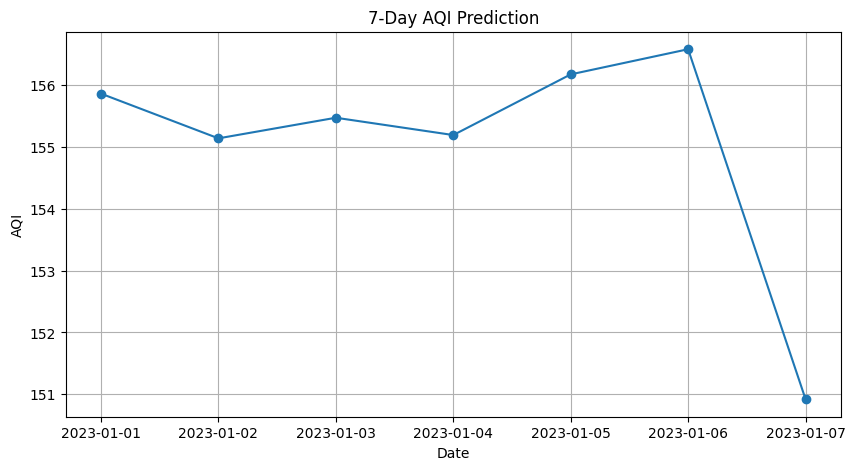

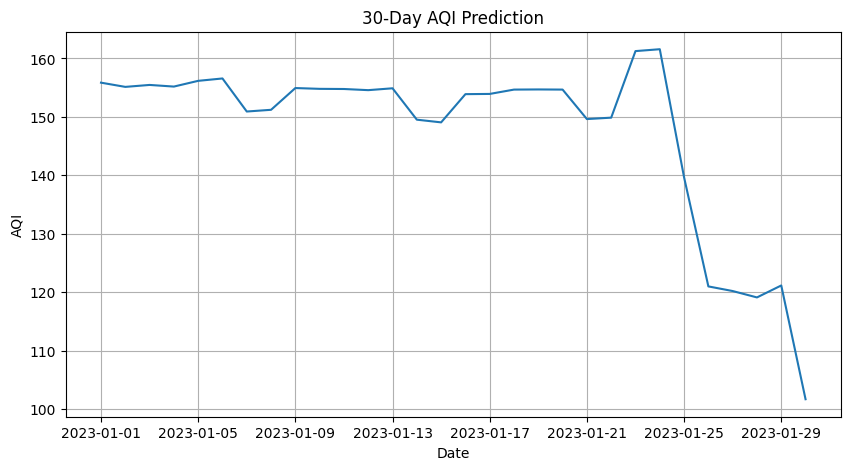

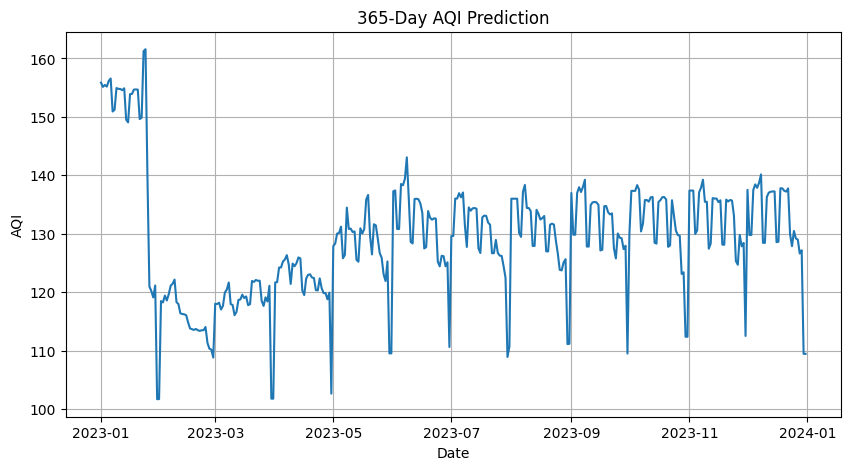

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

# ---------------------------------
# 1) Prepare future dataframe
# ---------------------------------
last_date = data['Date'].max()
last_aqi = data['AQI'].iloc[-1]   # last known AQI

def create_future_df(days):
    future_dates = [last_date + timedelta(days=i) for i in range(1, days+1)]
    f = pd.DataFrame({"Date": future_dates})

    # features needed
    f["Day"] = f["Date"].dt.day
    f["Month_num"] = f["Date"].dt.month
    f["Year"] = f["Date"].dt.year
    f['DayOfYear'] = f['Date'].dt.dayofyear
    f['WeekOfYear'] = f['Date'].dt.isocalendar().week
    f['IsWeekend'] = (f['Date'].dt.weekday >= 5).astype(int)

    # ---- KEY FIX: Add AQI_lag1 ----
    f["AQI_lag1"] = last_aqi  # assume last known AQI for prediction

    return f

future_7 = create_future_df(7)
future_30 = create_future_df(30)
future_365 = create_future_df(365)

# ---------------------------------
# 2) Predict using correct features
# ---------------------------------
features = ['Day','Month_num','Year','DayOfYear','WeekOfYear','IsWeekend','AQI_lag1']

future_7['Predicted_AQI'] = model.predict(future_7[features])
future_30['Predicted_AQI'] = model.predict(future_30[features])
future_365['Predicted_AQI'] = model.predict(future_365[features])

# ---------------------------------
# 3) Save Excel files
# ---------------------------------
future_7.to_excel("AQI_Prediction_7_Days.xlsx", index=False)
future_30.to_excel("AQI_Prediction_30_Days.xlsx", index=False)
future_365.to_excel("AQI_Prediction_365_Days.xlsx", index=False)

print("Files Saved:")
print("✔ AQI_Prediction_7_Days.xlsx")
print("✔ AQI_Prediction_30_Days.xlsx")
print("✔ AQI_Prediction_365_Days.xlsx")

# ---------------------------------
# 4) Plot Graphs
# ---------------------------------
plt.figure(figsize=(10,5))
plt.plot(future_7["Date"], future_7["Predicted_AQI"], marker='o')
plt.title("7-Day AQI Prediction")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(future_30["Date"], future_30["Predicted_AQI"])
plt.title("30-Day AQI Prediction")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(future_365["Date"], future_365["Predicted_AQI"])
plt.title("365-Day AQI Prediction")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.grid(True)
plt.show()
